# 03 - Wrong-Way Risk Analysis

This notebook uses the existing WWR output files. It does not run a new simulation.

In [1]:
from pathlib import Path
import os

project_dir = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(project_dir)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

mkdir -p failed for path C:\Users\Administrator\.matplotlib: [WinError 5] Access is denied: 'C:\\Users\\Administrator\\.matplotlib'


Matplotlib created a temporary cache directory at C:\Users\ADMINI~1\AppData\Local\Temp\1\matplotlib-1h7ujbjz because there was an issue with the default path (C:\Users\Administrator\.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [3]:
credit = pd.read_csv('outputs/counterparty_credit.csv')
wwr_profile = pd.read_csv('outputs/wwr_profile.csv')
wwr_summary = pd.read_csv('outputs/wwr_summary.csv')
correlation_sweep = pd.read_csv('outputs/wwr_correlation_sweep.csv')
scatter_sample = pd.read_csv('outputs/wwr_scatter_sample.csv')
distribution_sample = pd.read_csv('outputs/wwr_distribution_sample.csv')

## Credit assumptions

In [4]:
display(credit)

,counterparty,initial_hazard,long_run_hazard,mean_reversion,credit_volatility,recovery_rate,wwr_market_factor,wwr_correlation,severe_wwr_correlation,wwr_rate_correlation,severe_wwr_rate_correlation,netting_set
0,Bank A,0.015,0.018,0.70,0.06,0.40,SP500,0.4,0.7,0.0,0.0,NS_BANK_A
1,Bank B,0.025,0.030,0.80,0.08,0.40,NASDAQ100,-0.4,-0.7,-0.2,-0.3,NS_BANK_B
2,Fund C,0.020,0.024,0.65,0.07,0.35,SP500,0.4,0.7,0.0,0.0,NS_FUND_C


The market paths are identical in every credit scenario. Therefore ordinary EE is also identical.

In [5]:
ee_check = wwr_profile.pivot_table(
    index=['counterparty', 'time_years'],
    columns='scenario',
    values='ee'
)

maximum_difference = (ee_check.max(axis=1) - ee_check.min(axis=1)).max()
print('Maximum ordinary EE difference between scenarios:', maximum_difference)

Maximum ordinary EE difference between scenarios: 0.0


## Ordinary and default-weighted exposure

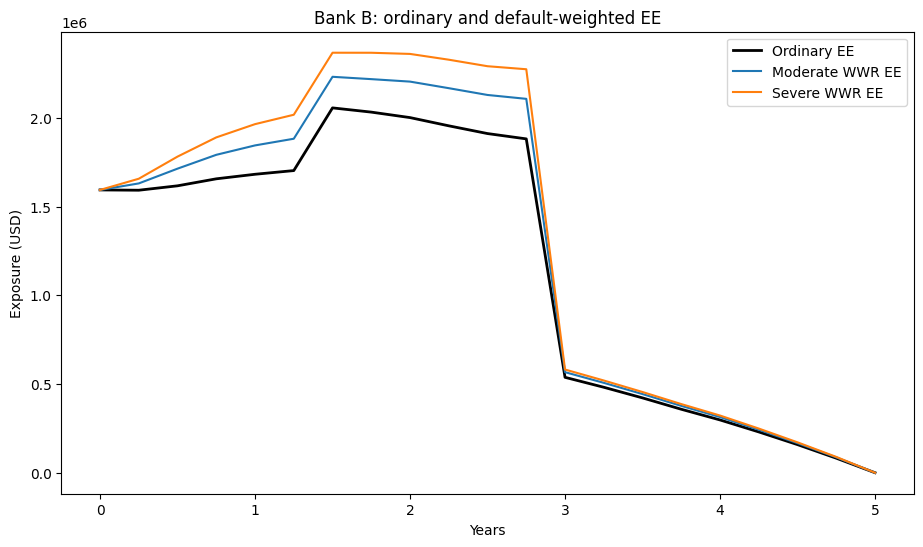

In [6]:
bank_b = wwr_profile[wwr_profile['counterparty'] == 'Bank B']
ordinary = bank_b[bank_b['scenario'] == 'independent']

plt.figure(figsize=(11, 6))
plt.plot(ordinary['time_years'], ordinary['ee'], label='Ordinary EE', color='black', linewidth=2)

for scenario in ['moderate', 'severe']:
    data = bank_b[bank_b['scenario'] == scenario]
    plt.plot(data['time_years'], data['default_weighted_ee'], label=scenario.title() + ' WWR EE')

plt.title('Bank B: ordinary and default-weighted EE')
plt.xlabel('Years')
plt.ylabel('Exposure (USD)')
plt.legend()
plt.show()

## CVA comparison

In [7]:
display(wwr_summary)

,scenario,counterparty,netting_set,cva,recovery_rate,market_factor,market_correlation,rate_correlation,independent_cva,cva_uplift,cva_uplift_pct
0,independent,Bank A,NS_BANK_A,12279.071425,0.40,SP500,0.0,0.0,12279.071425,0.000000,0.000000
1,independent,Bank B,NS_BANK_B,86137.328464,0.40,NASDAQ100,0.0,0.0,86137.328464,0.000000,0.000000
2,independent,Fund C,NS_FUND_C,10514.253078,0.35,SP500,0.0,0.0,10514.253078,0.000000,0.000000
3,moderate,Bank A,NS_BANK_A,14077.283885,0.40,SP500,0.4,0.0,12279.071425,1798.212460,14.644531
4,moderate,Bank B,NS_BANK_B,93869.720067,0.40,NASDAQ100,-0.4,-0.2,86137.328464,7732.391603,8.976818
5,moderate,Fund C,NS_FUND_C,11817.604232,0.35,SP500,0.4,0.0,10514.253078,1303.351154,12.396041
6,severe,Bank A,NS_BANK_A,15494.512767,0.40,SP500,0.7,0.0,12279.071425,3215.441343,26.186356
7,severe,Bank B,NS_BANK_B,99383.482646,0.40,NASDAQ100,-0.7,-0.3,86137.328464,13246.154182,15.377949
8,severe,Fund C,NS_FUND_C,12854.215160,0.35,SP500,0.7,0.0,10514.253078,2339.962082,22.255143


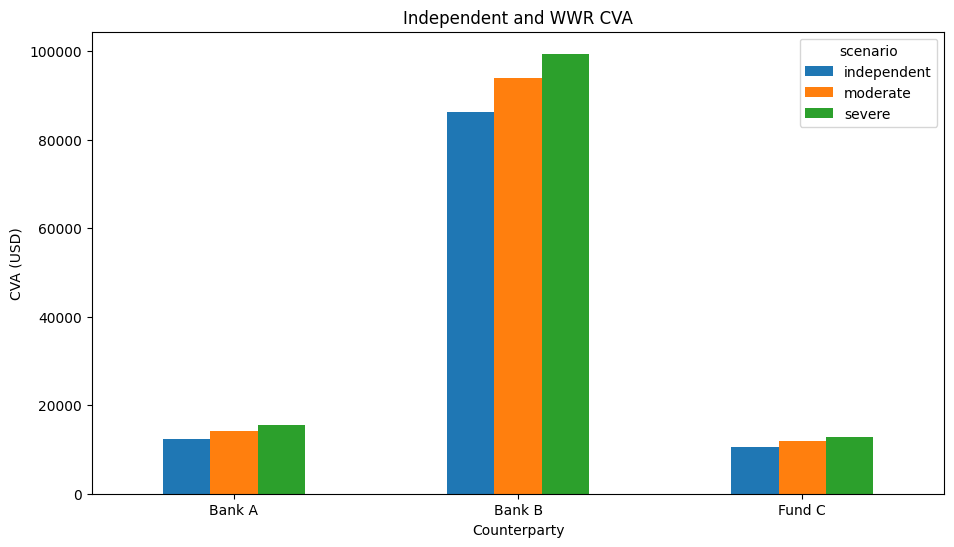

In [8]:
cva_table = wwr_summary.pivot(index='counterparty', columns='scenario', values='cva')
cva_table = cva_table[['independent', 'moderate', 'severe']]

cva_table.plot(kind='bar', figsize=(11, 6))
plt.title('Independent and WWR CVA')
plt.xlabel('Counterparty')
plt.ylabel('CVA (USD)')
plt.xticks(rotation=0)
plt.show()

## Correlation sensitivity

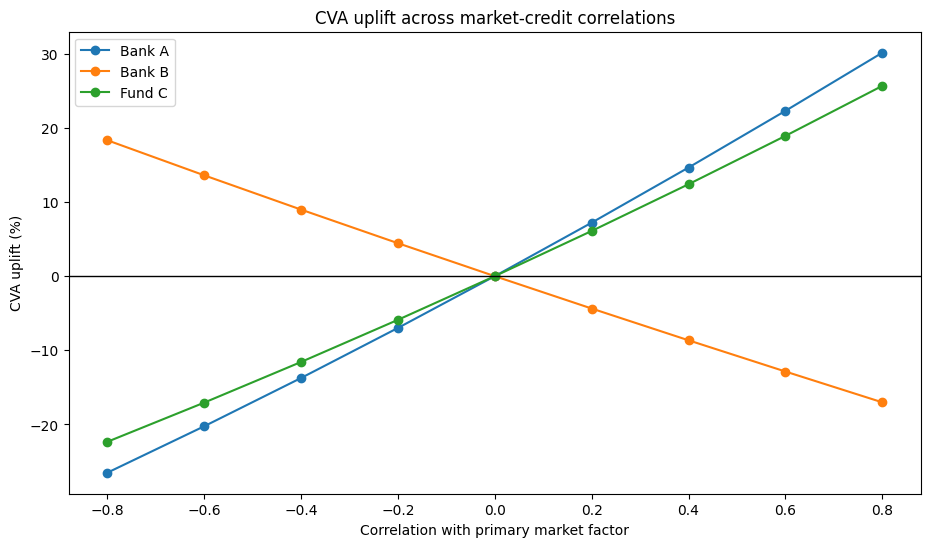

In [9]:
plt.figure(figsize=(11, 6))

for counterparty, data in correlation_sweep.groupby('counterparty'):
    plt.plot(data['correlation'], data['cva_uplift_pct'], marker='o', label=counterparty)

plt.axhline(0, color='black', linewidth=1)
plt.title('CVA uplift across market-credit correlations')
plt.xlabel('Correlation with primary market factor')
plt.ylabel('CVA uplift (%)')
plt.legend()
plt.show()

For Bank B, negative correlation produces WWR because exposure rises when NASDAQ and rates fall while its hazard rate rises.

## Exposure and hazard rate

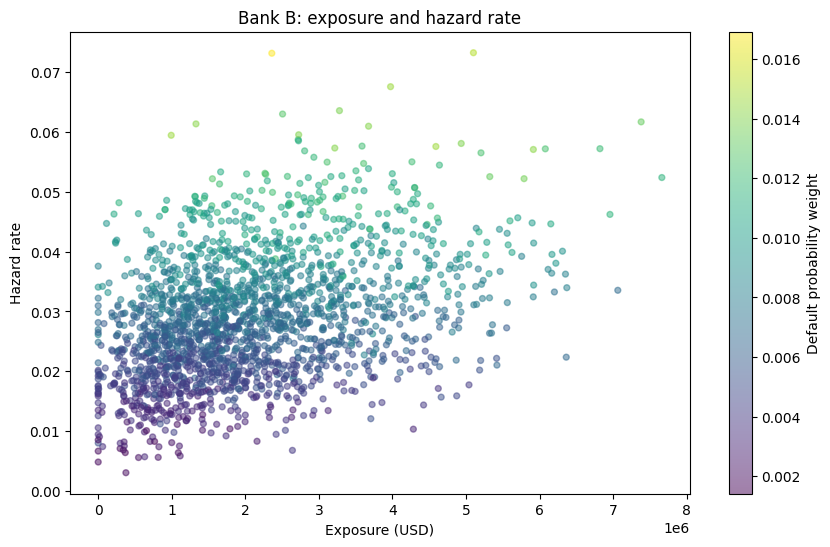

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(
    scatter_sample['exposure'],
    scatter_sample['hazard_rate'],
    c=scatter_sample['default_weight'],
    alpha=0.5,
    s=18
)
plt.colorbar(label='Default probability weight')
plt.title('Bank B: exposure and hazard rate')
plt.xlabel('Exposure (USD)')
plt.ylabel('Hazard rate')
plt.show()

## Default-weighted exposure distribution

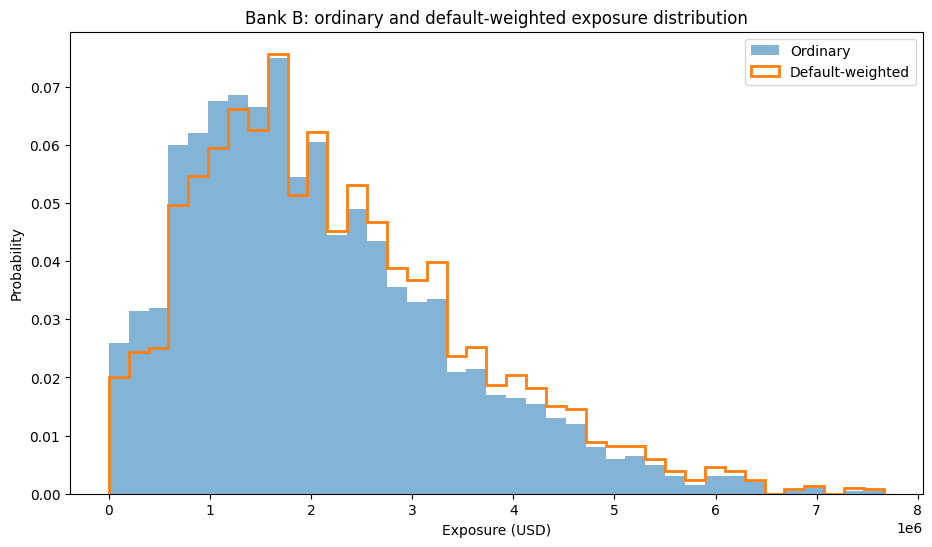

In [11]:
values = distribution_sample['exposure']
bins = np.linspace(values.min(), values.max(), 40)

plt.figure(figsize=(11, 6))
plt.hist(values, bins=bins, weights=distribution_sample['ordinary_weight'], alpha=0.55, label='Ordinary')
plt.hist(values, bins=bins, weights=distribution_sample['default_weight'], histtype='step', linewidth=2, label='Default-weighted')
plt.title('Bank B: ordinary and default-weighted exposure distribution')
plt.xlabel('Exposure (USD)')
plt.ylabel('Probability')
plt.legend()
plt.show()

## Correlation stress heatmap

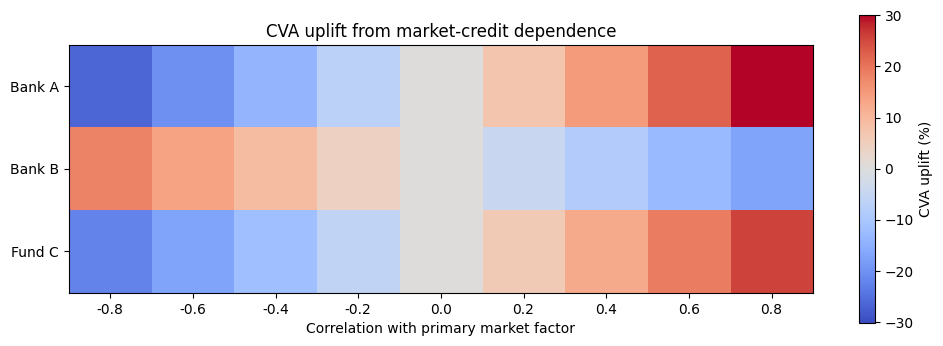

In [12]:
heatmap = correlation_sweep.pivot(index='counterparty', columns='correlation', values='cva_uplift_pct')
limit = np.abs(heatmap.values).max()

fig, ax = plt.subplots(figsize=(12, 4))
image = ax.imshow(heatmap.values, cmap='coolwarm', vmin=-limit, vmax=limit)
ax.set_xticks(np.arange(len(heatmap.columns)), heatmap.columns)
ax.set_yticks(np.arange(len(heatmap.index)), heatmap.index)
ax.set_xlabel('Correlation with primary market factor')
ax.set_title('CVA uplift from market-credit dependence')
fig.colorbar(image, ax=ax, label='CVA uplift (%)')
plt.show()